In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import json
import sys

# Introduction to numerical methods

This notebook introduces the basic ideas behind numerical computing: how numbers are represented in a computer, how arithmetic behaves in floating-point arithmetic, and how we can use Python and NumPy to perform numerical calculations reliably.

A central theme is that computers do not store real numbers exactly. Every calculation is therefore affected by finite precision, rounding, and approximation errors.


<b>Lecture:</b> János Török<br>
<b>Practice:</b> Bendegúz Nyári, Kristóf Benedek<br>

# Class 1: Numbers

This first lecture focuses on the foundations of numerical algorithms. Before we study approximation methods, we must understand how data is represented in a computer and how Python stores different kinds of values.

The key questions are:
- what is a number in binary?
- why do floating-point calculations have tiny errors?
- how do we write stable numerical code in practice?


## Required knowledge
This course assumes that you already know the basic Python building blocks used throughout numerical work:

- loops and conditions
- variables and data types
- indexing and slicing
- functions and basic control flow

The examples below are meant to refresh these ideas before we move to numerical algorithms and floating-point behavior.


### loops and conditions

In [2]:
#range runs from 0 to n-1
for i in range(4):
    print(i)

0
1
2
3


In [ ]:
#from,to,steps
for a in range(3,9,2):
    print(a)

# Explanation:
# range(start, stop, step) creates values starting at 'start',
# stopping before 'stop', and increasing by 'step'.
# Here we get: 3, 5, 7.


3
5
7


In [4]:
#identation indicate code blocks (here loop and condition)
for a in range(9):
    if a < 5:
        print(a)
    else:
        print(-a)

0
1
2
3
4
-5
-6
-7
-8


In [5]:
#same in two ways:
for i in range(9):
    if i > 5:
        print(i)
print("#######")
for i in range(9):
    if i <=5: continue
    print(i)
#The first one is preferred by purists, but in python the second is also good practice if used properly,
# to avoid excess indentations

6
7
8
#######
6
7
8


In [6]:
#while loop
i = 0
while i < 5:
    i += 1
    print(i)
print("END",i)

1
2
3
4
5
END 5


In [7]:
#while loop exit on condition
i = 0
while True:
    i += 1
    if i > 4:
        break
print("END",i)

END 5


### Variable types
Python supports several core data types that are used repeatedly in numerical computations:

- integers: whole numbers such as $2$, $-7$, $42$
- floating-point numbers: real numbers such as $3.14$, $1.0$, $1\times10^{-10}$
- strings: text values such as "alma"
- lists: ordered collections of values
- tuples: immutable ordered collections
- sets: unordered collections with unique elements
- dictionaries: mappings from keys to values

We now review each type with small examples.


<b>integer</b>

An integer is a whole number. In Python, integers are exact and do not lose precision as long as they fit in memory.

Examples:
- $4$
- $-10$
- $2^{10}$

Python can do arithmetic with integers exactly, including division with floor semantics using `//` and the remainder using `%`.


In [8]:
# Integer
a = 4
print(type(a))
print(a//2, a//3, a//4, a//5)
#modulus
print("modulus:",a%3,a%7)
# power
print("power:",2**3)

<class 'int'>
2 1 1 0
modulus: 1 4
power: 8


<b>floating point</b>

A floating-point number is a real number stored in a finite binary representation. This means that many numbers cannot be represented exactly in the computer, even if they look simple in decimal notation.

For example, $0.1$, $0.2$, and $0.3$ are not exact binary fractions, so repeated arithmetic may produce tiny numerical errors.


In [9]:
# Floating point
b = 2.2
c = 1.0
d = 1e-10
print(b,c,d)
print(type(c))

2.2 1.0 1e-10
<class 'float'>


In [10]:
# Back and forth to integer
print(a/1,float(a),int(b))

4.0 4.0 2


<b>string</b>

A string is text data. Strings can be combined, repeated, and indexed just like sequences in Python.

Example:
- "alma" + "korte" gives "almakorte"
- 2 * "alma" gives "almaalma"

The expression `t + 1` fails because Python does not know how to add a number to a string.


In [11]:
#string
s = "alma"
t = "korte"
print(s,t,s+t,2*s)
print(type(s))

alma korte almakorte almaalma
<class 'str'>


In [ ]:
#not everything is possible:
print(t+1)

# This intentionally raises a TypeError because a string cannot be added to an integer.
# The purpose is to demonstrate Python's type rules.


TypeError: can only concatenate str (not "int") to str

<b>list</b>

A list is an ordered collection of values. Lists can contain numbers, strings, other lists, and any Python objects.

Important ideas:
- the order matters
- elements can be accessed by index
- values can be added or removed
- slices create subsets of the list

Lists are one of the most common structures in Python and are used heavily in numerical work.


In [13]:
#lists contain arbitrary elements one after the other
l = [a,b,t]
print(l)
print(type(l))

[4, 2.2, 'korte']
<class 'list'>


In [14]:
#lists may contain lists as elements
l2 = [c,l]
print(l2)

[1.0, [4, 2.2, 'korte']]


In [15]:
#referencing them
print(l2[0])
print(l2[1])
print(l2[1][1])

1.0
[4, 2.2, 'korte']
2.2


In [16]:
#list comprehension
l = [i**2 for i in range(2,6)]
print(l)
l = [i**2 for i in range(2,6) if i%2 == 0]
print(l)

[4, 9, 16, 25]
[4, 16]


In [17]:
#making list from a range
print(range(5))
print(list(range(5)))

range(0, 5)
[0, 1, 2, 3, 4]


In [18]:
#adding and removing elements from the list
l = list(range(5))
l.append("8")
print("Append:",l)
l.remove(2)
print("Remove:",l)

Append: [0, 1, 2, 3, 4, '8']
Remove: [0, 1, 3, 4, '8']


In [19]:
#loop through elements
for le in l:
    print(le)

0
1
3
4
8


In [20]:
#loop with index
for i,le in enumerate(l):
    print(i,le)
for i in range(len(l)):
    print(i,l[i])

0 0
1 1
2 3
3 4
4 8
0 0
1 1
2 3
3 4
4 8


In [21]:
l.remove(2)

ValueError: list.remove(x): x not in list

In [22]:
x = 3
if x in l:
    l.remove(x)
else:
    print("the list does not contain x")
print(l)

[0, 1, 4, '8']


In [23]:
#removes the last element and returns it
m = l.pop()
print(l,m)

[0, 1, 4] 8


In [24]:
#remove elmement i
l = list(range(5))
m = l.pop(2)
print(m,l)

2 [0, 1, 3, 4]


In [25]:
#remove elmement i
l = [5,2,8,2,9,"4"]
i = l.index(2)
print(m,i)

2 1


In [ ]:
#index gives an error if the item is not in the list so again we have to check with 'in'
print(l.index(4))

# This line intentionally raises a ValueError, because 4 is not present in the list.
# It is a demonstration of how Python reacts to a missing element.


ValueError: 4 is not in list

In [27]:
#referencing ranges:
l = list(range(10))
print(l)
print(l[3:4]) # =[3] first included, the last isn't
print(l[-4:-3]) # =[6] - goes backwards, -1 is 9 here -2 is 8 -3 is 7, and -4 is 6 which is the result
print(l[4:3], l[-3:-4]) # [],[] both are empty, as the first index is larger than the second
print(l[1:7:2]) # =[1, 3, 5] from 1 to 7 (not included), by steps of 2

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[3]
[6]
[] []
[1, 3, 5]


<b>tuple</b><br>
A tuple is similar to a list, but it is immutable: once created, its contents cannot be changed. Tuples are often used as fixed data records or as dictionary keys.

For example, `(1, 2)` is a tuple, while `[1, 2]` is a list. The key difference is that a tuple cannot be modified after creation.


In [28]:
print(type([1,2]),type((1,2)))

<class 'list'> <class 'tuple'>


In [29]:
lt = (1,2)
print(lt,lt[1])

(1, 2) 2


In [ ]:
lt[1] = 1

# This should fail because tuples are immutable.
# The purpose of this cell is to demonstrate the error clearly.


TypeError: 'tuple' object does not support item assignment

In [31]:
#sort lists
print(sorted([8,3,7,4,9]))
print(sorted([8,3,7,4,9],reverse=True))

[3, 4, 7, 8, 9]
[9, 8, 7, 4, 3]


<b>copying</b>

When you assign one list or array to another variable, you may create a reference to the same object rather than a new object.

This is important because modifying one variable can affect the other. To avoid this, use `.copy()` when you need independent data.


In [32]:
l = [1,2,3]
k = l
k[0] = 7
print(k,l) # they are the same

[7, 2, 3] [7, 2, 3]


In [33]:
l = [1,2,3]
k = l.copy()
k[0] = 7
print(k,l) # they are not the same

[7, 2, 3] [1, 2, 3]


<b>set</b>

A set is an unordered collection of unique elements. It is useful when we want to remove duplicates or perform standard set operations such as union and intersection.

Example:
- `set([1, 2, 3])`
- `s1.union(s2)`
- `s1.intersection(s2)`

A set does not preserve order, so it should not be used when the sequence matters.


In [34]:
#similar to list but all element may appear only once
s = set()
l = list()
l.append(1)
l.append(1)
l.append(2)
s.add(1)
s.add(1)
s.add(2)
print(l,s)
print(set(l))
print(type(s))

[1, 1, 2] {1, 2}
{1, 2}
<class 'set'>


In [35]:
#standard set operations
#union
s1 = set([1,2,3])
s2 = set([3,4,5])
print(s1.union(s2))
print(s1.intersection(s2))
#etc...

{1, 2, 3, 4, 5}
{3}


<b>dictionary</b><br>
A dictionary stores data as key-value pairs. Each key is unique and can be a string, integer, tuple, or another hashable value.

This is a very important structure in numerical programming because it allows us to map names to values or store structured information efficiently.

Example:
- `d[15643] = "2^14"`
- `d["more"] = "Second level"`

Dictionaries are not ordered in the same sense as lists, but they allow fast lookup by key.


In [36]:
d = dict()
d[15643] = "2^14"
d["2^14"] = 16384
d["more"] = dict()
d["more"] = "Second level"
print(d)

{15643: '2^14', '2^14': 16384, 'more': 'Second level'}


In [37]:
#dictionary is just json, print it out nicely
print(json.dumps(d, indent=4))

{
    "15643": "2^14",
    "2^14": 16384,
    "more": "Second level"
}


In [38]:
#from string to dictionary:
s = '{"a":1,"b":2}'
d = json.loads(s)
print(d,type(d))

{'a': 1, 'b': 2} <class 'dict'>


In [39]:
#tuple as index
d[(1,2)] = [1,2]
print(d)

{'a': 1, 'b': 2, (1, 2): [1, 2]}


In [ ]:
# the last one does not work other way around
# This line is intentionally broken to show that a list cannot be used as a dictionary key.
# Lists are mutable and therefore not hashable.
d[[1,2]] = (1,2)


TypeError: unhashable type: 'list'

In [ ]:
#tuple is not in json
print(d)
print("#########")
print(json.dumps(d, indent=4))

{'a': 1, 'b': 2, (1, 2): [1, 2]}
#########


TypeError: keys must be str, int, float, bool or None, not tuple

In [41]:
#delete it and check again:
del(d[(1,2)])
print(json.dumps(d, indent=4))

{
    "a": 1,
    "b": 2
}


In [42]:
dd = dict()
dd[np.int(2)] = np.complex128(1+2.3j)
print(json.dumps(dd, indent=4))

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [43]:
#get parts:
print(d.items())
print(d.keys())
print(d.values())

dict_items([('a', 1), ('b', 2)])
dict_keys(['a', 'b'])
dict_values([1, 2])


In [44]:
for k,v in d.items():
    print(k,":",v)

a : 1
b : 2


In [45]:
d = dict()
d["a"] = 27
d["g"] = 18
d["bcbc"] = 355
d["af"] = 99

In [46]:
#create a tuple which is sorted by value
sorted_by_value = sorted(d.items(), key=lambda kv: kv[1])
print(sorted_by_value)

[('g', 18), ('a', 27), ('af', 99), ('bcbc', 355)]


## Numbers
This section explains how numbers are represented inside a computer and why numerical calculations can produce small errors.

The two most important ideas are:
- integers are represented exactly in Python,
- floating-point numbers are represented approximately in binary,
- therefore, repeated floating-point operations may lead to rounding error.

The next examples show both the representation and the consequences of finite precision.


In [47]:
# numbers are stored in binary format
for i in range(10):
    print(i,bin(i))

0 0b0
1 0b1
2 0b10
3 0b11
4 0b100
5 0b101
6 0b110
7 0b111
8 0b1000
9 0b1001


In [48]:
# negative numbers
for i in range(10):
    print(-i,bin(-i))

0 0b0
-1 -0b1
-2 -0b10
-3 -0b11
-4 -0b100
-5 -0b101
-6 -0b110
-7 -0b111
-8 -0b1000
-9 -0b1001


In [49]:
#author: DeanM@stackoverflow
def int2bin(integer, digits):
    if integer >= 0:
        return bin(integer)[2:].zfill(digits)
    else:
        return bin(2**digits + integer)[2:]

In [50]:
# 8 bit integer
for i in range(10):
    print(i,int2bin(i,8))

0 00000000
1 00000001
2 00000010
3 00000011
4 00000100
5 00000101
6 00000110
7 00000111
8 00001000
9 00001001


In [51]:
s = "00000110" # the problem is s is indexed from the left not from the right
a = 0
j = 1
for i in reversed(range(len(s))): # reversed goes backwards
    if s[i] == "1":
        a += j
    j *= 2
print("a:",a % (2**8-1)) # we work with 8 bit numbers so get rid of the rest
a = a % (2**8-1)
if a >= 2**7-1:
    print(a-2**8)
else:
    print(a)

a: 6
6


In [52]:
# 8 bit integer
for i in range(10):
    print(-i,int2bin(-i,8))

0 00000000
-1 11111111
-2 11111110
-3 11111101
-4 11111100
-5 11111011
-6 11111010
-7 11111001
-8 11111000
-9 11110111


In [53]:
s = "11111010" # the problem is s is indexed from the left not from the right
a = 0
j = 1
for i in reversed(range(len(s))): # reversed goes backwards
    if s[i] == "1":
        a += j
    j *= 2
print("a:",a & (2**8-1)) # a better and more traditional way of going back to 8 bit works only with numbers 2**n
a = a & (2**8-1)
if a >= 2**7-1:
    print(a-2**8)
else:
    print(a)

a: 250
-6


In [54]:
sys.int_info
#only 30 bits of 32 are used to store the integer the other two are type information

sys.int_info(bits_per_digit=30, sizeof_digit=4, default_max_str_digits=4300, str_digits_check_threshold=640)

<b>Floating point</b>

In the IEEE-754 format, a floating-point number is stored as:

$$
(-1)^s \, (1 + f) \, 2^{e - 1023}
$$

where:
- $s$ is the sign bit,
- $e$ is the exponent,
- $f$ is the fractional part of the mantissa.

This representation is efficient and standard, but it cannot store every real number exactly. The result is that arithmetic such as $0.1 + 0.2$ is not always exactly equal to $0.3$ in binary floating-point arithmetic.


Representation<br>
<img src="https://pythonnumericalmethods.studentorg.berkeley.edu/_images/09.02.01-Binary_neg_12.png" width=680px>
<br>
There are three parts: sign $s$, exponent $e$ and fraction $f$. The value:
$$n = (-1)^s\cdot (1+f)\cdot 2^{e-1023}$$
The sign is $s=1$, the exponent in decimal is $e=1\cdot 2^{10}+1\cdot 2^1=1024+2=1026$, the fraction is $f=1\cdot \frac{1}{2^1}+0\cdot \frac{1}{2^2}\dots=0.5$. Therefore $n=(−1)^1\cdot (1+0.5)\cdot2^{1026-1023}=-1\cdot 1.5\cdot2^3=−12.0$
 (base10).

#### Problems
There are only finitely many floating-point numbers available in a fixed-size format. For example, a 64-bit floating-point number has around $2^{64}$ possible bit patterns, but not all real numbers can be stored exactly.

In practice, this means:
- values may be rounded,
- repeated operations can accumulate error,
- comparisons like `0.1 + 0.2 == 0.3` may fail.

This is not a bug in Python; it is a consequence of how real numbers are represented in computers.


In [55]:
if 0.1+0.2==0.3:
    print("Math is ok")
else:
    print("This should not happen!")

This should not happen!


In [56]:
0.1+0.2-0.3

5.551115123125783e-17

In [57]:
a = 0.1
b = 0.2
c = 0.3
if abs(a+b-c) < 1e-16:
    print("Math is ok with some small error")
else:
    print("This should not happen!")

Math is ok with some small error


In [58]:
a = 0.1
b = 0.2
c = 0.3
s = 0.0
for _ in range(1000):
    s += a
    s += b
for _ in range(1000):
    s -= c
if abs(s) < 1e-16:
    print("Math is ok with some small error", s)
else:
    print("This should not happen!", s)

This should not happen! -1.139943694994372e-11


In [59]:
a = 0.1
b = 0.2
c = 0.3
s = 0.0
for _ in range(1000):
    s += a
    s += b
    s -= c
if abs(s) < 1e-16:
    print("Math is ok with some small error", s)
else:
    print("This should not happen!", s)

Math is ok with some small error 5.551115123125783e-17


Calculate:
$$ s=\sum_{i=1}^{1000}\frac{i}{1000}$$

In [60]:
a = 1/1000
b = 0.0
s = 0.0
for i in range(1000):
    b += a
    s += b
print(s)

500.50000000000034


In [61]:
#always use the direct formula:
a = 1/1000
b = 0.0
s = 0.0
for i in range(1000):
    b = (i+1) * a
    s += b
print(s)

500.5


Most famous example:
<a href="https://www.youtube.com/watch?v=ei58gGM9Z8k">The Minecraft boat-drop mystery</a> (external video)

### Canonical example exponential

The following example introduces the mathematical idea behind the exponential function and shows how a numerical approximation can be built from a recurrence.

The exponential function is defined by the infinite series

$$
e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots = \sum_{n=0}^{\infty} \frac{x^n}{n!}
$$

The next term can be obtained from the previous one:

$$
\frac{x^n}{n!} = \frac{x}{n} \cdot \frac{x^{n-1}}{(n-1)!}
$$

This recurrence is useful in code because we can compute the next term by multiplying the previous term by $x/n$. In the example below, `vn1` holds the current term and is updated iteratively.

We will not use the `math` and `random` modules here because `numpy` provides the required numerical functionality in a more consistent way.


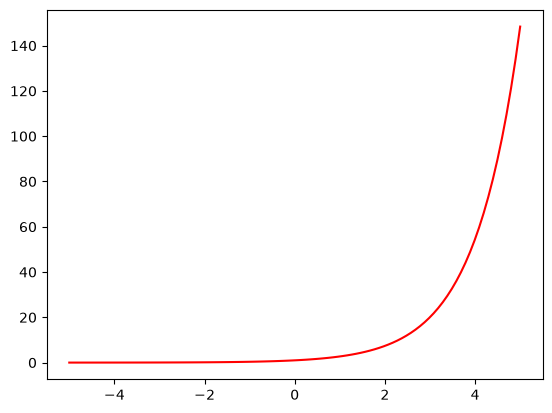

In [62]:
x = np.linspace(-5,5,100)
plt.plot(x,np.exp(x),"r-")

In [63]:
def myexp(x):
    #initial value 
    vn1 = 1.0
    e = 1.0
    prev_e = -1.0 # previous value used for stop contition
    n = 1
    while np.abs(prev_e - e) > 0:
        prev_e = e #save the previous value
        vn1 *= x / n # the new value of the sum
        e += vn1 # add it!
        n += 1 # increase index
    return e

In [64]:
print(np.exp(0.1),myexp(0.1))

1.1051709180756477 1.1051709180756473


In [65]:
print(np.exp(20),myexp(20))

485165195.4097903 485165195.40979046


In [66]:
print(np.exp(-20),myexp(-20),1.0/myexp(20))

2.061153622438558e-09 6.147561828914626e-09 2.061153622438557e-09


### NumPy

`numpy` is the central numerical library in Python. It provides efficient arrays, vectorized operations, linear algebra tools, mathematical functions, and random number generation.

It is important not to mix `numpy` with the standard-library `math` and `random` modules for numerical tasks, because they have different behavior and precision characteristics. In numerical work, we usually want the consistent array-based behavior provided by `numpy`.

The next cells show the main ideas behind arrays, indexing, and numerical operations.


In [67]:
a = np.arange(10)
b = range(10)
print(a,b,list(b))
print(type(a),type(b))
#please note the subtle difference of missing commas. Do not rely on it! 

[0 1 2 3 4 5 6 7 8 9] range(0, 10) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
<class 'numpy.ndarray'> <class 'range'>


In [68]:
#numpy array and list can be made fromeach other
b = [1,2,3]
print(type(b),b,b[0])
a = np.array(b)
print(type(a),a,a[0])
c = list(a)
print(type(c),c,c[0])

<class 'list'> [1, 2, 3] 1
<class 'numpy.ndarray'> [1 2 3] 1
<class 'list'> [np.int64(1), np.int64(2), np.int64(3)] 1


In [69]:
#numpy cannot mix types, if the list does it will take the most incluseive one, here the string
np.array([1,"a",1.5])
#here float
np.array([1,1.5,7])

array([1. , 1.5, 7. ])

In [70]:
#very efficient in storage. I have 8 byte integers by default:
a = np.arange(10000)
b = np.arange(100000)
print(sys.getsizeof(a),sys.getsizeof(b))

80112 800112


In [71]:
#list first stores a list of pointers to the elements which are in turn stored individually in the memory.
la = [i for i in range(10000)]
print(sys.getsizeof(la))
print(sys.getsizeof(la[0]))

85176
28


In [72]:
la = ["A LONG STRING THAT DEFINITELY"+str(i)+" DOES NOT FIT" for i in range(10000)]
print(sys.getsizeof(la))
print(sys.getsizeof(la[0]))

85176
84


In [73]:
#the extra space stores the shape of the numpy array. reshaping is cheap:
a = np.array([1,2,3,4,5,6])
b = np.array([[1,2,3],[4,5,6]])
print(np.ndim(a))
print(np.ndim(b),np.ndim(b[0]))
print(a.reshape(2,3),a.reshape(2,3).ndim)

1
2 1
[[1 2 3]
 [4 5 6]] 2


In [74]:
#obviously:
a = np.array([1,2,3,4,5,6])
c = a.reshape(2,4)

ValueError: cannot reshape array of size 6 into shape (2,4)

In [ ]:
#zeros is the default way to create a numpy array. Always define the type!!!!!!!! Though default is float.
a = np.zeros((3,3))
b = np.zeros((3,3),dtype=int)
print(a)
print(b)
c = np.ones(5,dtype=np.uint8) #8 bit unsigned integer
print(c)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[0 0 0]
 [0 0 0]
 [0 0 0]]
[1 1 1 1 1]


In [ ]:
#indexing, and slicing
a = np.zeros((3,3),dtype=int)
print("a=",a)
a[0][1] = 1
a[1, 2] = 3.5 # just to show that it will be converted back to integer
print("\na=",a)
a[:,0:3:2] = 2  # slicing. The single : means all rows/columns/whatever comes after it in the third dimension
print("\na=",a)

a= [[0 0 0]
 [0 0 0]
 [0 0 0]]

a= [[0 1 0]
 [0 0 3]
 [0 0 0]]

a= [[2 1 2]
 [2 0 2]
 [2 0 2]]


In [ ]:
c[0] += 255
print(c)
#it is zero as a 8 bit unsigned goes from 0 to 255

[0 1 1 1 1]


In [ ]:
# operations on the whole array or on a part of it
a = np.zeros((3,3),dtype=float)
a[1] += 1
print(a)
a[:,2] += 2
print(a)

[[0. 0. 0.]
 [1. 1. 1.]
 [0. 0. 0.]]
[[0. 0. 2.]
 [1. 1. 3.]
 [0. 0. 2.]]


In [ ]:
a = a*(-1)
print(a)

[[-0. -0. -2.]
 [-1. -1. -3.]
 [-0. -0. -2.]]


In [ ]:
#but
a[:2,::2] = a[:2,::2] + 10
print(a)

[[10. -0.  8.]
 [ 9. -1.  7.]
 [-0. -0. -2.]]


In [ ]:
a[:2,::2] += np.ones((2,2))*10
print(a)

[[20. -0. 18.]
 [19. -1. 17.]
 [-0. -0. -2.]]


In [ ]:
# columns and rows
a = np.arange(9).reshape(3,3)
print(a)
print("")
print(a[1])
print(a[:,1])

[[0 1 2]
 [3 4 5]
 [6 7 8]]

[3 4 5]
[1 4 7]


#### Random numbers
Random numbers in Python are generated by algorithms and are therefore called pseudo-random numbers. They are generated from a previous value, and the starting value is called the seed.

If no seed is given, the system time is often used. Setting a seed has several advantages:

* the code is reproducible,
* debugging is easier,
* parallel computations can be made consistent.

This section demonstrates how to generate random values and how to use them for probability-based simulations.


In [ ]:
np.random.seed(12345)
a = np.random.random(10)
print(a)

[0.92961609 0.31637555 0.18391881 0.20456028 0.56772503 0.5955447
 0.96451452 0.6531771  0.74890664 0.65356987]


In [ ]:
#events with given probability. Here 30%
N = 10
p = 0.3
for i in range(N):
    if np.random.random() < p:
        print("It happened in step %d." % (i))

It happened in step 2.
It happened in step 3.
It happened in step 4.


In [ ]:
# do it in one step
p = 0.3
r = np.random.random(10) < p
print(r)

[False False False False False False False False False  True]


In [ ]:
#the True/False array can be used as an index to restrict the other array to the True part
np.arange(10)[r]

array([9])

In [ ]:
np.where(r)

(array([9]),)

In [ ]:
# Other useful random functions:
print(np.random.choice(5, 10))
print(np.random.choice(5,3,replace=False))
print(np.random.choice(5, 10, p=[0.1, 0, 0.3, 0.6, 0]))
c = ["Budapest", "Pécs", "Debrecen", "Miskolc"]
print(np.random.choice(c,1))
print(np.random.choice(c,2))
sr = np.arange(5)
np.random.shuffle(sr)
print(sr)

[3 1 3 1 3 4 0 0 3 2]
[0 1 4]
[3 2 2 3 3 2 0 2 3 2]
['Budapest']
['Miskolc' 'Budapest']
[0 1 3 2 4]


In [ ]:
# shape of the array
np.random.seed(12345)
a = np.random.random(size=(2,5))
print(a)

[[0.92961609 0.31637555 0.18391881 0.20456028 0.56772503]
 [0.5955447  0.96451452 0.6531771  0.74890664 0.65356987]]


<b>copying</b>

In [ ]:
a = np.arange(5)
b = a
b[3] = 9
print(a,b) #they are the same

[0 1 2 9 4] [0 1 2 9 4]


In [ ]:
a = np.arange(5)
b = a.copy()
b[3] = 9
print(a,b) #they are not the same

[0 1 2 3 4] [0 1 2 9 4]


In [ ]:
a = np.arange(6).reshape(3,2)
b = a[0:2]
b[1,1] = 9
print(a,"\n",b) #they are not the same

[[0 1]
 [2 9]
 [4 5]] 
 [[0 1]
 [2 9]]


## Functions

In [ ]:
def f1(x):
    x = x + 1
    return x

In [ ]:
x = 2
print(f1(x),x)

3 2


In [ ]:
def f2(l): #changes also the original
    l[0] += 1
    return(l)

In [ ]:
l = [1,2,3]
print(f2(l),l)

[2, 2, 3] [2, 2, 3]


In [ ]:
f3 = lambda x: x%7
l = [1,3,7,9]
print(sorted(l, key = f3))

[7, 1, 9, 3]


In [ ]:
def addfirst(x, getfirst = lambda x:x):
    return getfirst(x) + 1

In [ ]:
addfirst(5)

6

In [ ]:
addfirst([5,4,3])

TypeError: can only concatenate list (not "int") to list

In [ ]:
addfirst([5,4,3],getfirst = lambda x:x[0])

6

## Random number example
Typical problem: We have an array with many values and we have to change them randomly with a given probability `p`

First for loop

In [ ]:
N = 1000000
p = 0.00001
a = np.zeros(N,dtype=float)

In [ ]:
for i in range(N):
    if np.random.random() < p:
        a[i] = np.random.normal(0,0.1)

In [ ]:
%%timeit
a = np.zeros(N,dtype=float)
for i in range(N):
    if np.random.random() < p:
        a[i] = np.random.normal(0,0.1)

271 ms ± 3.99 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
a = np.zeros(N,dtype=float)
r = np.random.random(N) < p
a[r] = np.random.normal(0,0.1,size=r.sum())

In [ ]:
%%timeit
a = np.zeros(N,dtype=float)
r = np.random.random(N) < p
a[r] = np.random.normal(0,0.1,size=r.sum())

5.92 ms ± 87.1 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
n = np.random.binomial(N,p)
print(n)

6


Idea: We "know" how many number will be changed, or at least the distribution of it: binomial. So we generate a number with binomial distribution and only that many random numbers and positions. The problem with python is that the positions is tricky to get, as we have a terrible implementation of `np.random.choice` with the `replace=False` option.

In [ ]:
%%timeit
a = np.zeros(N,dtype=float)
n = np.random.binomial(N,p)
a[np.random.choice(N,n,replace=False)] = np.random.normal(0,0.1,size=n)

13 ms ± 176 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%%timeit
a = np.zeros(N,dtype=float)
n = np.random.binomial(N,p)
a[np.random.choice(N,n)] = np.random.normal(0,0.1,size=n)

272 µs ± 6.43 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
